In [1]:
import osmnx as ox
import shapely.geometry as geom
import networkx as  nx
from shapely.geometry import box
import os
import numpy as np
import json

In [3]:
import geopandas as gpd

# Load shapefiles
nodes = gpd.read_file("mydata/network_porto/porto_nodes.shp")
edges = gpd.read_file("mydata/network_porto/porto_edges.shp")
# nodes = nodes.to_crs("EPSG:32629")
# edges = edges.to_crs("EPSG:32629")
# Build graph
G = nx.MultiDiGraph()
G.graph["crs"] = "EPSG:4326"
# Add nodes
for _, row in nodes.iterrows():
    G.add_node(
        row["osmid"],
        x=row["x"],
        y=row["y"],
        **row.drop(["geometry", "x", "y"]).to_dict()
    )

# Add edges
for _, row in edges.iterrows():
    
    G.add_edge(
        row["u"], 
        row["v"],
        geometry=row.geometry,
        **row.drop(["geometry", "u", "v"]).to_dict()
    )


In [4]:
patch_size = 0.01

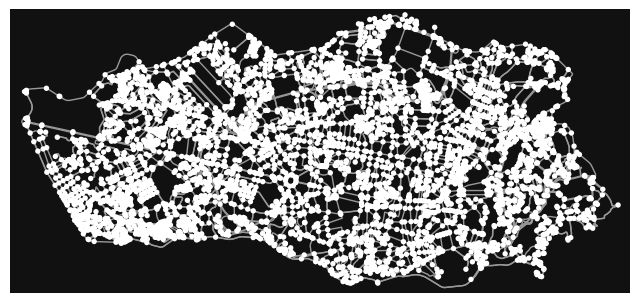

In [5]:
import matplotlib.pyplot as plt

# Define bounding box (lon_min, lat_min, lon_max, lat_max)
bbox = (-8.6886988, 41.1406333, -8.5559061 + patch_size, 41.1858412 + patch_size)

# Download the driving network within this box
porto_graph = G

# Plot the graph
fig, ax = ox.plot_graph(porto_graph)

In [6]:
HIGHWAY_TYPES = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified',
    'residential', 'service', 'motorway_link', 'trunk_link', 'primary_link'
]

In [7]:
NIGHT_POIS = {
    "bar",
    "pub",
    "nightclub",
    "restaurant",
    "fast_food"
}

In [8]:
DAYTIME_POIS = {
    "school",
    "college",
    "university",
    "kindergarten",
    "bus_station"
}

In [9]:
SERVICE_POIS = {
    "hospital",
    "clinic"
}

In [10]:
COMMERCIAL_POIS = {
    "supermarket",
    "bank",
    "pharmacy",
    "mall",
    "retail"
}

In [11]:
BUILDING_POIS = {
    "residential",
    "apartments",
    "house",
    "commercial",
    "industrial",
    "church"
}

In [12]:
tags = {
    "highway": True,          # All road types
    "amenity": True,         # All points of interest (schools, hospitals, etc.)
    "building": True,         # All building footprints
    "landuse": True,          # All landuse areas (parks, industrial, etc.)
}

In [13]:
minx, miny = -8.6886988, 41.1406333
maxx, maxy = -8.5559061 + patch_size, 41.1858412 + patch_size

In [14]:
city_bbox = (minx, miny, maxx, maxy)

In [16]:
all_features_gdf = ox.features.features_from_bbox(city_bbox, tags)

In [17]:
pois_gdf = all_features_gdf[all_features_gdf["amenity"].notna()]
buildings_gdf = all_features_gdf[all_features_gdf["building"].notna()]

In [18]:
nodes_ll = gpd.read_file("mydata/network_porto/porto_nodes.shp").to_crs("EPSG:4326")
edges_ll = gpd.read_file("mydata/network_porto/porto_edges.shp").to_crs("EPSG:4326")

pois_ll = pois_gdf.to_crs("EPSG:4326")
buildings_ll = buildings_gdf.to_crs("EPSG:4326")


In [19]:
nodes_m = nodes_ll.to_crs("EPSG:32629")
edges_m = edges_ll.to_crs("EPSG:32629")
pois_m = pois_ll.to_crs("EPSG:32629")
buildings_m = buildings_ll.to_crs("EPSG:32629")

In [20]:
patch_size_deg = 0.01
context_ratio = 1.5

minx, miny = -8.6886988, 41.1406333
maxx, maxy = -8.5559061, 41.1858412

In [25]:
street_counts = ox.stats.count_streets_per_node(porto_graph)


In [22]:
import numpy as np

FAST_ROADS = {"motorway", "trunk", "primary"}
MEDIUM_ROADS = {"secondary", "tertiary"}
SLOW_ROADS = {"residential", "living_street", "service"}

def extract_osm_features_from_gdf(sub_nodes, sub_edges, sub_pois, sub_buildings):
    """
    Extract OSM features from a patch.
    Always returns the same keys with zero defaults if data is missing.
    """
    # Initialize features with defaults
    features = {
        # Road topology
        "num_nodes": 0,
        "num_edges": 0,
        "mean_degree": 0.0,
        "num_intersections": 0,
        "num_deadends": 0,
        "total_road_length": 0.0,
        "avg_road_length": 0.0,
        "num_roundabout": 0,
        # Highway counts
        "highway_motorway": 0,
        "highway_trunk": 0,
        "highway_primary": 0,
        "highway_secondary": 0,
        "highway_tertiary": 0,
        "highway_residential": 0,
        "highway_living_street": 0,
        "highway_service": 0,
        # POIs
        "poi_night": 0,
        "poi_daytime": 0,
        "poi_service": 0,
        "poi_commercial": 0,
        # Buildings
        "build_residential": 0,
        "build_commercial": 0,
        "build_industrial": 0
    }

    # ===== Road topology =====
    if len(sub_nodes) > 0:
        degrees = sub_nodes["street_count"].fillna(0)
        features["num_nodes"] = len(sub_nodes)
        features["mean_degree"] = float(degrees.mean())
        features["num_intersections"] = int((degrees >= 3).sum())
        features["num_deadends"] = int((degrees == 1).sum())

    if len(sub_edges) > 0:
        lengths = sub_edges["length"].fillna(0)
        features["num_edges"] = len(sub_edges)
        features["total_road_length"] = float(lengths.sum())
        features["avg_road_length"] = float(lengths.mean()) if len(lengths) > 0 else 0.0
        features["num_roundabout"] = int((sub_edges.get("junction", "") == "roundabout").sum())

        highway_tags = sub_edges["highway"].astype(str)
        uniq, counts = np.unique(highway_tags, return_counts=True)
        for u, c in zip(uniq, counts):
            key = f"highway_{u}"
            if key in features:
                features[key] = int(c)

    # ===== POI =====
    if len(sub_pois) > 0:
        amenities = sub_pois["amenity"].astype(str)
        if "NIGHT_POIS" in globals():
            features["poi_night"] = int(amenities.isin(NIGHT_POIS).sum())
        if "DAYTIME_POIS" in globals():
            features["poi_daytime"] = int(amenities.isin(DAYTIME_POIS).sum())
        if "SERVICE_POIS" in globals():
            features["poi_service"] = int(amenities.isin(SERVICE_POIS).sum())
        if "COMMERCIAL_POIS" in globals():
            features["poi_commercial"] = int(amenities.isin(COMMERCIAL_POIS).sum())

    # ===== Buildings =====
    if len(sub_buildings) > 0:
        buildings = sub_buildings["building"].astype(str)
        features["build_residential"] = int((buildings == "residential").sum())
        features["build_commercial"] = int((buildings == "commercial").sum())
        features["build_industrial"] = int((buildings == "industrial").sum())

    return features


In [28]:
import os
import json
from shapely.geometry import box

def save_patches_osm_features(
    nodes_ll, edges_ll,
    pois_ll, buildings_ll,
    out_dir,
    patch_size_deg=0.002,
    context_ratio=1.5
):
    """
    Split the area into square patches, extract OSM features for each patch,
    and save the metadata as JSON.
    """
    os.makedirs(out_dir, exist_ok=True)
    patch_id = 0
    metadata = []

    # Padding for context
    pad = patch_size_deg * (context_ratio - 1) / 2
    nodes_ll["street_count"] = nodes_ll["osmid"].map(street_counts).fillna(0).astype(int)
    print(nodes_ll.columns)
    print(nodes_ll["street_count"].describe())
    # Compute area bounds
    minx, miny, maxx, maxy = nodes_ll.total_bounds

    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            # Create patch bbox with context
            bbox_ll = box(
                x - pad, y - pad,
                x + patch_size_deg + pad,
                y + patch_size_deg + pad
            )

            # Select geometries within patch
            sub_nodes = nodes_ll[nodes_ll.within(bbox_ll)]
            sub_edges = edges_ll[edges_ll.intersects(bbox_ll)]
            sub_pois = pois_ll[pois_ll.within(bbox_ll)]
            sub_buildings = buildings_ll[buildings_ll.within(bbox_ll)]

            # Skip empty patches
            if len(sub_nodes) == 0 and len(sub_edges) == 0 and len(sub_buildings) == 0:
                y += patch_size_deg
                continue

            # Extract features
            features = extract_osm_features_from_gdf(
                sub_nodes, sub_edges, sub_pois, sub_buildings
            )

            # Save metadata
            metadata.append({
                "patch_id": patch_id,
                "center": {
                    "lon": x + patch_size_deg / 2,
                    "lat": y + patch_size_deg / 2
                },
                "bbox": {
                    "min_lon": x,
                    "min_lat": y,
                    "max_lon": x + patch_size_deg,
                    "max_lat": y + patch_size_deg
                },
                "features": features
            })

            patch_id += 1
            y += patch_size_deg
        x += patch_size_deg

    # Write JSON
    out_file = os.path.join(out_dir, "patch_osm_features.json")
    with open(out_file, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {patch_id} patches to {out_file}")


In [29]:
import shutil, os

save_patches_osm_features(
    nodes_ll=nodes_ll, edges_ll=edges_ll,
    pois_ll=pois_ll,
    buildings_ll=buildings_ll,
    out_dir=f"mydata/osm_feature_{patch_size_deg}", patch_size_deg=patch_size_deg)
    

Index(['osmid', 'y', 'x', 'street_cou', 'highway', 'ref', 'junction',
       'railway', 'geometry', 'street_count'],
      dtype='object')
count    5062.000000
mean        2.851442
std         0.793956
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: street_count, dtype: float64
Saved 70 patches to mydata/osm_feature_0.01\patch_osm_features.json
